<a href="https://colab.research.google.com/github/ikramkdr/MLSec-Project/blob/main/mlsec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook evaluates the robustness of state-of-the-art CIFAR-10 models
from RobustBench under distribution shift.

We compare robustness on:
- CIFAR-10 (standard benchmark)
- CIFAR-10.1 (natural distribution shift)

Robustness is evaluated using AutoAttack (Linf ε = 8/255).


# 1. Installing Required Libraries

In this section, we install the libraries required for the experiments.
We use **RobustBench** to load state-of-the-art robust models trained on CIFAR-10,
and **AutoAttack** to evaluate adversarial robustness under a strong attack setting.


In [1]:
!pip install git+https://github.com/RobustBench/robustbench.git
!pip install autoattack

  Cloning https://github.com/RobustBench/robustbench.git to /tmp/pip-req-build-ca_u4a9z
  Running command git clone --filter=blob:none --quiet https://github.com/RobustBench/robustbench.git /tmp/pip-req-build-ca_u4a9z
  Resolved https://github.com/RobustBench/robustbench.git to commit 78fcc9e48a07a861268f295a777b975f25155964
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to /tmp/pip-install-njkc8lne/autoattack_0b67d8f248804c9b9895781de048de93
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-install-njkc8lne/autoattack_0b67d8f248804c9b9895781de048de93
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4

# 2.Loading RobustBench Models

We evaluate three adversarially trained models from RobustBench.
These models represent different approaches to adversarial robustness
and allow us to compare their performance under distribution shift.

In [2]:
from robustbench.utils import load_model

model_new = load_model(model_name='Bartoldson2024Adversarial_WRN-94-16', dataset='cifar10', threat_model='Linf')
model_mid = load_model(model_name='Rebuffi2021Fixing_70_16_cutmix_extra', dataset='cifar10', threat_model='Linf')
model_old = load_model(model_name='Zhang2019Theoretically', dataset='cifar10', threat_model='Linf')

Downloading...
From (original): https://drive.google.com/uc?id=1g6o9H1b6vjoBi1USdCBt64C8B8LPiioX
From (redirected): https://drive.google.com/uc?id=1g6o9H1b6vjoBi1USdCBt64C8B8LPiioX&confirm=t&uuid=3696d869-ce63-4dc2-91d9-52ec8e5a8eb0
To: /content/models/cifar10/Linf/Bartoldson2024Adversarial_WRN-94-16.pt
100%|██████████| 1.46G/1.46G [00:23<00:00, 63.1MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1qKDTp6IJ1BUXZaRtbYuo_t0tuDl_4mLg
From (redirected): https://drive.google.com/uc?id=1qKDTp6IJ1BUXZaRtbYuo_t0tuDl_4mLg&confirm=t&uuid=7c4b740a-5a3d-428a-a689-9ba21d35c2b0
To: /content/models/cifar10/Linf/Rebuffi2021Fixing_70_16_cutmix_extra.pt
100%|██████████| 1.07G/1.07G [00:23<00:00, 45.2MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1hPz9QQwyM7QSuWu-ANG_uXR-29xtL8t_
From (redirected): https://drive.google.com/uc?id=1hPz9QQwyM7QSuWu-ANG_uXR-29xtL8t_&confirm=t&uuid=156f3673-3578-417d-90ce-c6603b97d91e
To: /content/models/cifar10/Linf/Zhang2019Theoretically.pt
100%|██████████| 193M/193M [00:03<00:00, 52.7MB/s]


# 3. Loading the Datasets

We load two datasets:

• **CIFAR-10**: the standard benchmark dataset used to train most robust models.  
• **CIFAR-10.1**: a slightly modified test set designed to evaluate robustness
under natural distribution shift.

To keep the evaluation manageable, we use a balanced subset of images (200 each )

In [3]:
import os
import numpy as np

# Downloading files of CIFAR-10.1(v6)
if not os.path.exists('cifar10.1_v6_data.npy'):
    !wget https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_data.npy
    !wget https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_labels.npy

# putting it in memory
data_10_1 = np.load('cifar10.1_v6_data.npy')
labels_10_1 = np.load('cifar10.1_v6_labels.npy')

print(f"CIFAR-10.1 charged : {data_10_1.shape[0]} images found.")

--2026-03-12 12:16:43--  https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_data.npy
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/modestyachts/CIFAR-10.1/master/datasets/cifar10.1_v6_data.npy [following]
--2026-03-12 12:16:44--  https://raw.githubusercontent.com/modestyachts/CIFAR-10.1/master/datasets/cifar10.1_v6_data.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6144128 (5.9M) [application/octet-stream]
Saving to: ‘cifar10.1_v6_data.npy’

cifar10.1_v6_data.n 100%[===================>]   5.86M  21.9MB/s    in 0.3s    

2026-03-12 12:16:45 (21.9 MB/s) - ‘cifar

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def get_balanced_subset(data, labels, n_per_class=20):
    x_list, y_list = [], []
    for i in range(10): # for 10 classes
        idx = np.where(labels == i)[0][:n_per_class]
        x_list.append(data[idx])
        y_list.append(labels[idx])

    # Converting to PyTorch , since Robustbench models use PyTorch
    x_final = torch.from_numpy(np.concatenate(x_list)).permute(0, 3, 1, 2).float() / 255.0
    y_final = torch.from_numpy(np.concatenate(y_list)).long()
    return x_final, y_final

# Creating the test data
x_test_v21, y_test_v21 = get_balanced_subset(data_10_1, labels_10_1)

print(f"{x_test_v21.shape[0]} images are ready for the attack !")

200 images are ready for the attack !


In [5]:
from robustbench.data import load_cifar10

# Charging the 200 images of CIFAR-10 to compare
x_test_std, y_test_std = load_cifar10(n_examples=200)

100%|██████████| 170M/170M [00:15<00:00, 11.1MB/s]


# Visual Comparison Between CIFAR-10 and CIFAR-10.1

Before evaluating robustness, we visually compare examples from **CIFAR-10** and **CIFAR-10.1** belonging to the same class.

The goal is to highlight the **natural distribution shift** between the two datasets.  
Even though both datasets contain the same object classes, images in CIFAR-10.1 were collected independently and may present small differences in style, background, or viewpoint.

This comparison helps illustrate why models trained and evaluated only on CIFAR-10 may experience a performance drop when tested on CIFAR-10.1.

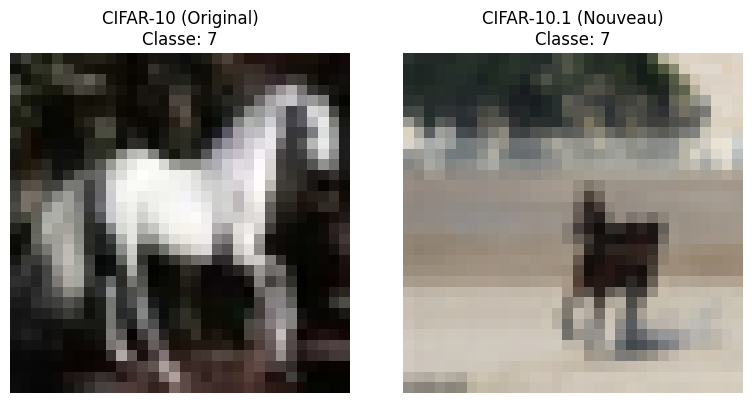

In [6]:
import matplotlib.pyplot as plt



def show_comparison(idx_class=0):
    # index of the first image of the class
    idx_10 = np.where(y_test_std.cpu() == idx_class)[0][0]
    idx_10_1 = np.where(labels_10_1 == idx_class)[0][0]

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    # Image CIFAR-10
    img10 = x_test_std[idx_10].cpu().permute(1, 2, 0).numpy()
    ax[0].imshow(img10)
    ax[0].set_title(f"CIFAR-10 (Original)\nClasse: {idx_class}")
    ax[0].axis('off')

    # Image CIFAR-10.1
    img10_1 = data_10_1[idx_10_1] / 255.0
    ax[1].imshow(img10_1)
    ax[1].set_title(f"CIFAR-10.1 (Nouveau)\nClasse: {idx_class}")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

show_comparison(idx_class=7)

# Robustness Evaluation with AutoAttack

In this section, we evaluate the robustness of a pretrained model from RobustBench on the two datasets:

First, we load the balanced subset of images from both datasets to ensure a fair comparison across all classes.

Then, we load a robust model from RobustBench and evaluate:

• **Clean accuracy** (performance on the original images)  
• **Robust accuracy** under adversarial perturbations generated with **AutoAttack (L∞, ε = 8/255)**

AutoAttack is an ensemble of strong attacks including **APGD-CE, APGD-T, FAB-T, and Square Attack**, which together provide a reliable estimate of worst-case adversarial robustness.

Finally, we compare the robustness of the model on CIFAR-10 and CIFAR-10.1 to analyze the effect of distribution shift.
## Model 1: Rebuffi2021

In [ ]:
import torch
import numpy as np
from autoattack import AutoAttack
from robustbench.utils import load_model
from robustbench.data import load_cifar10

# --- 1. CONFIGURATION ---
model_name = 'Rebuffi2021Fixing_70_16_cutmix_extra'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. data preparation ---
# CIFAR-10 Standard (200 images)
x_std, y_std = load_cifar10(n_examples=200)
x_std, y_std = x_std.to(device), y_std.to(device)

# CIFAR-10.1 (Subset of 200 images)
data_10_1 = np.load('cifar10.1_v6_data.npy')
labels_10_1 = np.load('cifar10.1_v6_labels.npy')

def get_balanced_subset(data, labels, n_per_class=20):
    x_list, y_list = [], []
    for i in range(10):
        idx = np.where(labels == i)[0][:n_per_class]
        x_list.append(data[idx])
        y_list.append(labels[idx])
    x_final = torch.from_numpy(np.concatenate(x_list)).permute(0, 3, 1, 2).float() / 255.0
    y_final = torch.from_numpy(np.concatenate(y_list)).long()
    return x_final.contiguous(), y_final.contiguous()

x_v21, y_v21 = get_balanced_subset(data_10_1, labels_10_1)
x_v21, y_v21 = x_v21.to(device), y_v21.to(device)

# --- 3. model loading ---
print(f"\n--- evaluation of the model : {model_name} ---")
model = load_model(model_name=model_name, dataset='cifar10', threat_model='Linf')
model = model.to(device).eval()

# --- 4. FONCTION D'ÉVALUATION COMPLÈTE ---
def evaluate_full(data, labels, dataset_name):
    print(f"\n>>> Evaluation on {dataset_name}")

    # Accuracy Natural (Clean)
    with torch.no_grad():
        output = model(data)
        acc_clean = (output.max(1)[1] == labels).float().mean().item() * 100
    print(f" Initial Accuracy  : {acc_clean:.2f}%")

    # AutoAttack Standard (lance APGD-CE, APGD-T, FAB-T, Square)
    adversary = AutoAttack(model, norm='Linf', eps=8/255, version='standard', device=device)
    acc_robust = adversary.run_standard_evaluation(data, labels, bs=25)
    return acc_clean, acc_robust

# --- 5. lunching ---
# Test on CIFAR-10
clean_std, robust_std = evaluate_full(x_std, y_std, "CIFAR-10")

# Test on CIFAR-10.1
clean_v21, robust_v21 = evaluate_full(x_v21, y_v21, "CIFAR-10.1")

# --- 6. RÉSUMÉ FINAL ---
print("\n" + "="*50)
print(f"RÉSULTATS FINAUX : {model_name}")
print("="*50)
print(f"CIFAR-10  | Clean: {clean_std:.2f}% | Robust: {robust_std:.2f}%")
print(f"CIFAR-10.1 | Clean: {clean_v21:.2f}% | Robust: {robust_v21:.2f}%")
print(f"DROP ROBUSTE : {robust_std - robust_v21:.2f}%")
print("="*50)


--- evaluation of the model : Rebuffi2021Fixing_70_16_cutmix_extra ---

>>> Evaluation on CIFAR-10


## Model 2: Bartoldson 2024

In [ ]:
import torch
import numpy as np
from autoattack import AutoAttack
from robustbench.utils import load_model
from robustbench.data import load_cifar10

# --- 1. CONFIGURATION ---
model_name = 'Bartoldson2024Adversarial_WRN-94-16'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. PRÉPARATION DES DONNÉES ---
# CIFAR-10 Standard (200 images)
x_std, y_std = load_cifar10(n_examples=200)
x_std, y_std = x_std.to(device), y_std.to(device)

# CIFAR-10.1 (Subset équilibré de 200 images)
data_10_1 = np.load('cifar10.1_v6_data.npy')
labels_10_1 = np.load('cifar10.1_v6_labels.npy')

def get_balanced_subset(data, labels, n_per_class=20):
    x_list, y_list = [], []
    for i in range(10):
        idx = np.where(labels == i)[0][:n_per_class]
        x_list.append(data[idx])
        y_list.append(labels[idx])
    x_final = torch.from_numpy(np.concatenate(x_list)).permute(0, 3, 1, 2).float() / 255.0
    y_final = torch.from_numpy(np.concatenate(y_list)).long()
    return x_final.contiguous(), y_final.contiguous()

x_v21, y_v21 = get_balanced_subset(data_10_1, labels_10_1)
x_v21, y_v21 = x_v21.to(device), y_v21.to(device)

# --- 3. CHARGEMENT DU MODÈLE ---
print(f"\n--- ÉVALUATION DU MODÈLE : {model_name} ---")
model = load_model(model_name=model_name, dataset='cifar10', threat_model='Linf')
model = model.to(device).eval()

# --- 4. FONCTION D'ÉVALUATION COMPLÈTE ---
def evaluate_full(data, labels, dataset_name):
    print(f"\n>>> Évaluation sur {dataset_name}")

    # Accuracy Naturelle (Clean)
    with torch.no_grad():
        output = model(data)
        acc_clean = (output.max(1)[1] == labels).float().mean().item() * 100
    print(f"Accuracy Naturelle : {acc_clean:.2f}%")

    # AutoAttack Standard (lance APGD-CE, APGD-T, FAB-T, Square)
    adversary = AutoAttack(model, norm='Linf', eps=8/255, version='standard', device=device)
    acc_robust = adversary.run_standard_evaluation(data, labels, bs=25)
    return acc_clean, acc_robust

# --- 5. LANCEMENT ---
# Test sur CIFAR-10
clean_std, robust_std = evaluate_full(x_std, y_std, "CIFAR-10")

# Test sur CIFAR-10.1
clean_v21, robust_v21 = evaluate_full(x_v21, y_v21, "CIFAR-10.1")

# --- 6. RÉSUMÉ FINAL ---
print("\n" + "="*50)
print(f"RÉSULTATS FINAUX : {model_name}")
print("="*50)
print(f"CIFAR-10  | Clean: {clean_std:.2f}% | Robust: {robust_std:.2f}%")
print(f"CIFAR-10.1 | Clean: {clean_v21:.2f}% | Robust: {robust_v21:.2f}%")
print(f"DROP ROBUSTE : {robust_std - robust_v21:.2f}%")
print("="*50)

## Model 3: Zhang 2019

In [ ]:
import torch
import numpy as np
from autoattack import AutoAttack
from robustbench.utils import load_model
from robustbench.data import load_cifar10

# --- 1. CONFIGURATION ---
model_name ='Zhang2019Theoretically'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. PRÉPARATION DES DONNÉES ---
# CIFAR-10 Standard (200 images)
x_std, y_std = load_cifar10(n_examples=200)
x_std, y_std = x_std.to(device), y_std.to(device)

# CIFAR-10.1 (Subset équilibré de 200 images)
data_10_1 = np.load('cifar10.1_v6_data.npy')
labels_10_1 = np.load('cifar10.1_v6_labels.npy')

def get_balanced_subset(data, labels, n_per_class=20):
    x_list, y_list = [], []
    for i in range(10):
        idx = np.where(labels == i)[0][:n_per_class]
        x_list.append(data[idx])
        y_list.append(labels[idx])
    x_final = torch.from_numpy(np.concatenate(x_list)).permute(0, 3, 1, 2).float() / 255.0
    y_final = torch.from_numpy(np.concatenate(y_list)).long()
    return x_final.contiguous(), y_final.contiguous()

x_v21, y_v21 = get_balanced_subset(data_10_1, labels_10_1)
x_v21, y_v21 = x_v21.to(device), y_v21.to(device)

# --- 3. CHARGEMENT DU MODÈLE ---
print(f"\n--- ÉVALUATION DU MODÈLE : {model_name} ---")
model = load_model(model_name=model_name, dataset='cifar10', threat_model='Linf')
model = model.to(device).eval()

# --- 4. FONCTION D'ÉVALUATION COMPLÈTE ---
def evaluate_full(data, labels, dataset_name):
    print(f"\n>>> Évaluation sur {dataset_name}")

    # Accuracy Naturelle (Clean)
    with torch.no_grad():
        output = model(data)
        acc_clean = (output.max(1)[1] == labels).float().mean().item() * 100
    print(f"Accuracy Naturelle : {acc_clean:.2f}%")

    # AutoAttack Standard (lance APGD-CE, APGD-T, FAB-T, Square)
    adversary = AutoAttack(model, norm='Linf', eps=8/255, version='standard', device=device)
    acc_robust = adversary.run_standard_evaluation(data, labels, bs=25)
    return acc_clean, acc_robust

# --- 5. LANCEMENT ---
# Test sur CIFAR-10
clean_std, robust_std = evaluate_full(x_std, y_std, "CIFAR-10")

# Test sur CIFAR-10.1
clean_v21, robust_v21 = evaluate_full(x_v21, y_v21, "CIFAR-10.1")

# --- 6. RÉSUMÉ FINAL ---
print("\n" + "="*50)
print(f"RÉSULTATS FINAUX : {model_name}")
print("="*50)
print(f"CIFAR-10  | Clean: {clean_std:.2f}% | Robust: {robust_std:.2f}%")
print(f"CIFAR-10.1 | Clean: {clean_v21:.2f}% | Robust: {robust_v21:.2f}%")
print(f"DROP ROBUSTE : {robust_std - robust_v21:.2f}%")
print("="*50)

# Robust Accuracy Comparison

To better visualize the impact of distribution shift, we compare the **robust accuracy**
of the evaluated models on **CIFAR-10** and **CIFAR-10.1**.

The following bar chart highlights:
- the robust accuracy on the standard CIFAR-10 benchmark,
- the robust accuracy under distribution shift (CIFAR-10.1),
- and the **performance drop** observed for each model.

This visualization helps illustrate how robustness changes when models
are evaluated on slightly different data distributions.

In [ ]:
import plotly.graph_objects as go

# Models and robust drop
models = ["Bartoldson2024", "Rebuffi2021", "Zhang2019"]
robust_c10 = [76.5, 62.0, 51.0]
robust_c10_1 = [67.5, 57.5, 44.0]
drop = [r - r1 for r, r1 in zip(robust_c10, robust_c10_1)]

fig = go.Figure()

# CIFAR-10
fig.add_trace(go.Bar(
    x=models, y=robust_c10,
    name='Robust CIFAR-10',
    marker_color='green'
))

# CIFAR-10.1
fig.add_trace(go.Bar(
    x=models, y=robust_c10_1,
    name='Robust CIFAR-10.1',
    marker_color='orange'
))

for i, d in enumerate(drop):
    fig.add_annotation(
        x=models[i], y=max(robust_c10[i], robust_c10_1[i]) + 2,
        text=f"Drop: {d:.1f}%",
        showarrow=True,
        arrowhead=3,
        arrowsize=1,
        arrowcolor="red"
    )

fig.update_layout(
    title="Robust Accuracy Comparison: CIFAR-10 vs CIFAR-10.1",
    yaxis_title="Robust Accuracy (%)",
    barmode='group',
    template='plotly_white'
)
fig.show()